# Validation Notebook: Data Integrity + DeGroot Fit Checks

This notebook performs two checks:
1. Real-run data integrity audit for trajectory construction and message alignment.
2. Synthetic DeGroot recovery test (with noise) to validate fitting and evaluation logic.

In [1]:
from pathlib import Path
import sys
import numpy as np
import cvxpy as cp

MODELS_DIR = Path('..').resolve()
if str(MODELS_DIR) not in sys.path:
    sys.path.insert(0, str(MODELS_DIR))

from data_prep import (
    load_run_data,
    build_global_init_map,
    build_run_trajectory,
    build_neighbors_index,
    _numeric_agent_key,
    _bucket_events_to_slices,
    compute_required_time_slice_ms,
)
from plot_utils import (
    plot_observed_trajectories,
    plot_predicted_vs_observed,
    calculate_mean_and_variance,
    compute_wasserstein_distance,
)

ROOT = Path('../..').resolve()
CLEAN = ROOT / 'cleaned_data'
RUN_DIRS = sorted([p for p in CLEAN.iterdir() if p.is_dir()])

PARAMS = {
    'stance_clip': (-1.0, 1.0),
    'rollout_horizon_cap': 20,
}

TARGET_AGENT_FRACTION = 0.4
CONSTRAIN_MESSAGES = 150

print('Project root:', ROOT)
print('Runs found:', len(RUN_DIRS))

Project root: /Users/samuelli/Documents/code/llm/llm-network/modeling
Runs found: 67


In [2]:
RUN_DATA = {r.name: load_run_data(r) for r in RUN_DIRS}
GLOBAL_AGENT_IDS = sorted({a for d in RUN_DATA.values() for a in d['agent_ids']}, key=_numeric_agent_key)
N = len(GLOBAL_AGENT_IDS)

GLOBAL_INIT_BY_AGENT = build_global_init_map(RUN_DATA, GLOBAL_AGENT_IDS)
RUN_TRAJ_AND_MASK = {
    rn: build_run_trajectory(
        d,
        GLOBAL_AGENT_IDS,
        target_agent_fraction=TARGET_AGENT_FRACTION,
        return_post_mask=True,
        constrain_messages=CONSTRAIN_MESSAGES,
    )
    for rn, d in RUN_DATA.items()
}
RUN_TRAJ = {rn: tm[0] for rn, tm in RUN_TRAJ_AND_MASK.items()}
RUN_POST_MASK = {rn: tm[1] for rn, tm in RUN_TRAJ_AND_MASK.items()}
RUN_NEIGHBORS = {rn: build_neighbors_index(d, GLOBAL_AGENT_IDS) for rn, d in RUN_DATA.items()}

print('Global agents:', N)
print('Global init priors available:', len(GLOBAL_INIT_BY_AGENT))

Global agents: 30
Global init priors available: 30


In [3]:
def _same_or_both_nan(a, b, atol=1e-10):
    if np.isnan(a) and np.isnan(b):
        return True
    return np.isclose(a, b, atol=atol)

def audit_run_trajectory_integrity(run_name, data, traj, post_mask, global_agent_ids, target_agent_fraction, constrain_messages):
    agent_index = {a: i for i, a in enumerate(global_agent_ids)}
    slice_ms = compute_required_time_slice_ms(len(global_agent_ids), target_agent_fraction=target_agent_fraction)

    events = sorted(data.get('message_events', []), key=lambda x: x[0])
    if constrain_messages is not None:
        events = events[:constrain_messages]

    rebucketed, last_slice = _bucket_events_to_slices(events, slice_ms)
    expected_T = int(last_slice)
    issues = []

    if traj.shape[0] != expected_T + 1:
        issues.append(f'shape mismatch: traj T={traj.shape[0]-1}, expected T={expected_T}')

    posted_value_mismatches = 0
    missing_post_flags = 0
    carry_forward_mismatches = 0
    init_seed_mismatches = 0
    init_missing_seed_count = 0
    scale_like_init_count = 0
    scale_values = np.array([-1.0, -0.5, 0.0, 0.5, 1.0], dtype=float)

    for t, obs in rebucketed.items():
        for aid, val in obs.items():
            if aid not in agent_index:
                continue
            i = agent_index[aid]
            if not post_mask[t, i]:
                missing_post_flags += 1
            if not np.isclose(traj[t, i], float(val), atol=1e-10):
                posted_value_mismatches += 1

    for t in range(1, traj.shape[0]):
        for i in range(traj.shape[1]):
            if post_mask[t, i]:
                continue
            if not _same_or_both_nan(traj[t, i], traj[t - 1, i]):
                carry_forward_mismatches += 1

    slice0_obs = rebucketed.get(0, {})
    for aid in global_agent_ids:
        i = agent_index[aid]
        if aid in slice0_obs:
            continue

        profile = data['profile_seed_by_slice'].get(aid, {})
        if not profile:
            init_missing_seed_count += 1
            continue

        t0 = min(profile)
        expected_init = float(profile[t0])
        actual_init = float(traj[0, i])

        if not np.isclose(actual_init, expected_init, atol=1e-10):
            init_seed_mismatches += 1

        if np.any(np.isclose(actual_init, scale_values, atol=1e-12)):
            # These values are allowed if they came from profile seed; we count for visibility only.
            scale_like_init_count += 1

    ok = (
        posted_value_mismatches == 0
        and missing_post_flags == 0
        and carry_forward_mismatches == 0
        and init_seed_mismatches == 0
        and init_missing_seed_count == 0
        and len(issues) == 0
    )

    return {
        'run_name': run_name,
        'ok': ok,
        'shape_issues': issues,
        'posted_value_mismatches': posted_value_mismatches,
        'missing_post_flags': missing_post_flags,
        'carry_forward_mismatches': carry_forward_mismatches,
        'init_seed_mismatches': init_seed_mismatches,
        'init_missing_seed_count': init_missing_seed_count,
        'scale_like_init_count': scale_like_init_count,
        'traj_shape': tuple(traj.shape),
        'expected_last_slice': expected_T,
    }

audit_results = []
for rn in sorted(RUN_TRAJ.keys()):
    result = audit_run_trajectory_integrity(
        rn,
        RUN_DATA[rn],
        np.asarray(RUN_TRAJ[rn], dtype=float),
        np.asarray(RUN_POST_MASK[rn], dtype=bool),
        GLOBAL_AGENT_IDS,
        TARGET_AGENT_FRACTION,
        CONSTRAIN_MESSAGES,
    )
    audit_results.append(result)

num_ok = sum(1 for r in audit_results if r['ok'])
print(f'Integrity audit: {num_ok}/{len(audit_results)} runs passed fully')

for r in audit_results[:10]:
    print(
        r['run_name'],
        'OK' if r['ok'] else 'FAIL',
        f"posted_mismatch={r['posted_value_mismatches']}",
        f"missing_post_flags={r['missing_post_flags']}",
        f"carry_forward_mismatch={r['carry_forward_mismatches']}",
        f"init_seed_mismatch={r['init_seed_mismatches']}",
        f"init_missing_seed={r['init_missing_seed_count']}",
        f"scale_like_init={r['scale_like_init_count']}",
    )

failing = [r for r in audit_results if not r['ok']]
if failing:
    print('\nFirst failing run details:')
    print(failing[0])
else:
    print('\nAll runs passed integrity checks.')

Integrity audit: 67/67 runs passed fully
run_20260320-130058 OK posted_mismatch=0 missing_post_flags=0 carry_forward_mismatch=0 init_seed_mismatch=0 init_missing_seed=0 scale_like_init=0
run_20260320-133304 OK posted_mismatch=0 missing_post_flags=0 carry_forward_mismatch=0 init_seed_mismatch=0 init_missing_seed=0 scale_like_init=0
run_20260320-140500 OK posted_mismatch=0 missing_post_flags=0 carry_forward_mismatch=0 init_seed_mismatch=0 init_missing_seed=0 scale_like_init=0
run_20260320-143643 OK posted_mismatch=0 missing_post_flags=0 carry_forward_mismatch=0 init_seed_mismatch=0 init_missing_seed=0 scale_like_init=0
run_20260320-150827 OK posted_mismatch=0 missing_post_flags=0 carry_forward_mismatch=0 init_seed_mismatch=0 init_missing_seed=0 scale_like_init=0
run_20260320-154019 OK posted_mismatch=0 missing_post_flags=0 carry_forward_mismatch=0 init_seed_mismatch=0 init_missing_seed=0 scale_like_init=0
run_20260320-161210 OK posted_mismatch=0 missing_post_flags=0 carry_forward_mismatc

## Synthetic DeGroot Recovery Test

This section uses a known true DeGroot matrix to generate noisy synthetic trajectories,
then re-fits the matrix with the same fitting logic and checks recovery quality.

In [4]:
def build_dataset_from_run(run):
    X = []
    Y = []
    for t in range(len(run) - 1):
        X.append(run[t])
        Y.append(run[t + 1])
    X = np.array(X, dtype=float)
    Y = np.array(Y, dtype=float)
    return X, Y

def fit_row_stochastic_W_from_pooled_runs(run_traj_map, run_neighbors):
    run_names = sorted(run_traj_map.keys())
    ref_neighbors = run_neighbors[run_names[0]]

    for run_name in run_names[1:]:
        if run_neighbors[run_name] != ref_neighbors:
            raise ValueError('RUN_NEIGHBORS must be identical across runs for pooled fitting.')

    X_blocks = []
    Y_blocks = []
    for run_name in run_names:
        X, Y = build_dataset_from_run(np.asarray(run_traj_map[run_name], dtype=float))
        X_blocks.append(X)
        Y_blocks.append(Y)

    X_pool = np.vstack(X_blocks)
    Y_pool = np.vstack(Y_blocks)

    n = X_pool.shape[1]
    W = np.zeros((n, n), dtype=float)

    for i in range(n):
        ns = ref_neighbors[i]
        X_ns = X_pool[:, ns]
        y = Y_pool[:, i]

        w_ns = cp.Variable(len(ns))
        objective = cp.Minimize(cp.sum_squares(X_ns @ w_ns - y))
        constraints = [w_ns >= 0, cp.sum(w_ns) == 1]
        problem = cp.Problem(objective, constraints)
        problem.solve()

        row = np.zeros(n, dtype=float)
        row[ns] = np.asarray(w_ns.value, dtype=float).ravel()
        W[i] = row

    return W, X_pool, Y_pool

def degroot_rollout_prediction(W, x0, horizon):
    predictions = [x0]
    current_x = x0.copy()
    for t in range(horizon):
        current_x = W @ current_x
        predictions.append(current_x.copy())
    return predictions

Synthetic recovery summary
  Relative Frobenius error on W: 1.246384932781636e-16 6
  One-step pooled MSE: 0.0
  Avg flattened corr(obs, pred): 1.0
  Avg Wasserstein(obs, pred): 0.0


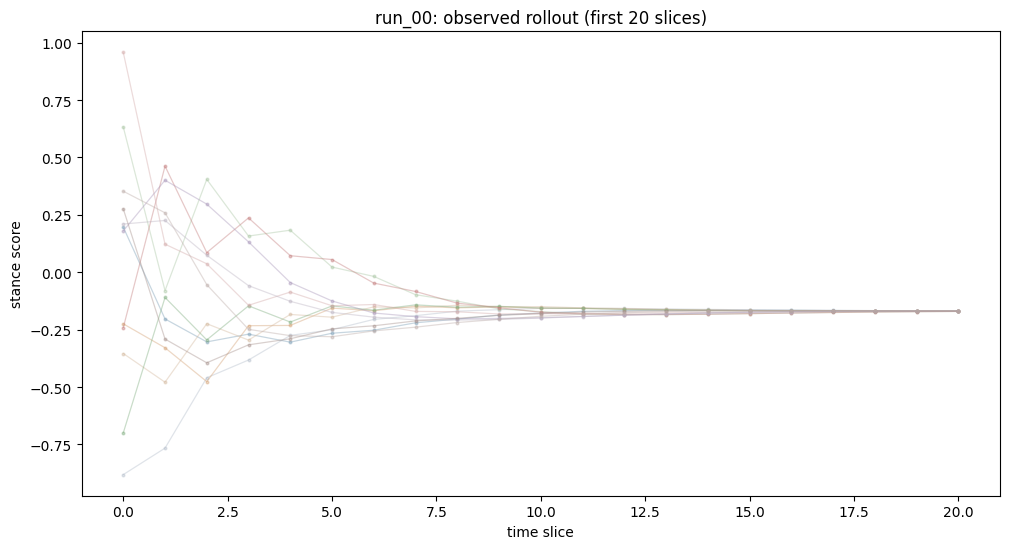

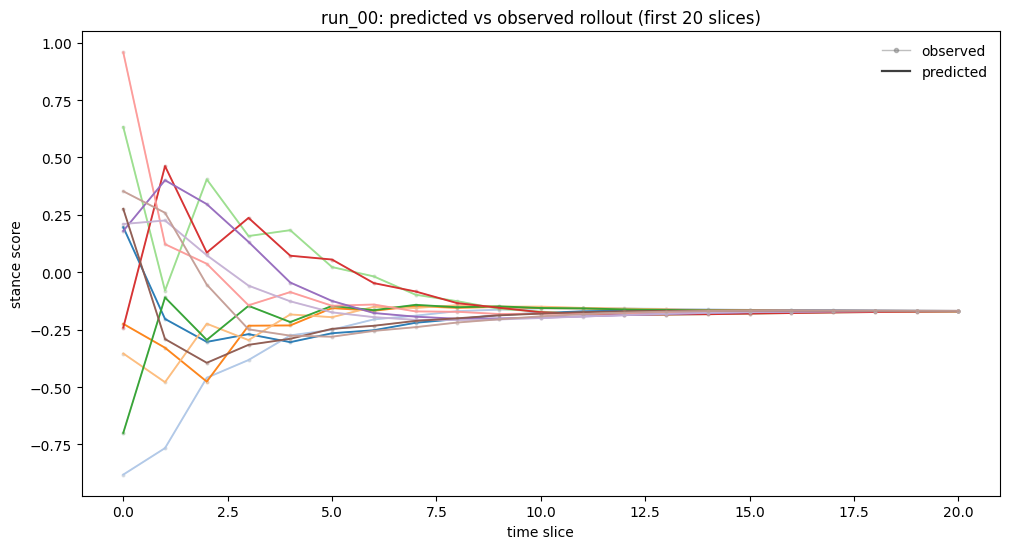

Sample run metrics: {'run': 'run_00', 'steady_mean_obs': -0.16935975238614953, 'steady_mean_pred': -0.16935975238614942, 'steady_var_obs': 2.0524507296308927e-06, 'steady_var_pred': 2.052450729630907e-06, 'wasserstein': 8.913174431328453e-17, 'corr': 1.0}


In [5]:
rng = np.random.default_rng(7)
n_agents = 12
n_runs = 10
horizon = PARAMS['rollout_horizon_cap']
noise_std = 0.0

synthetic_neighbors = {}
for i in range(n_agents):
    base = {(i - 1) % n_agents, i, (i + 1) % n_agents}
    extra = {(i + 3) % n_agents}
    ns = sorted(base | extra)
    synthetic_neighbors[i] = ns

W_true = np.zeros((n_agents, n_agents), dtype=float)
for i in range(n_agents):
    ns = synthetic_neighbors[i]
    w = rng.dirichlet(np.ones(len(ns)))
    W_true[i, ns] = w

SYN_RUN_TRAJ = {}
for r in range(n_runs):
    x = rng.uniform(-1.0, 1.0, size=n_agents)
    states = [x.copy()]
    for _ in range(horizon):
        x_next = W_true @ x
        x_next = np.clip(x_next + rng.normal(0.0, noise_std, size=n_agents), -1.0, 1.0)
        states.append(x_next.copy())
        x = x_next
    SYN_RUN_TRAJ[f'run_{r:02d}'] = np.asarray(states, dtype=float)

SYN_NEIGHBORS_BY_RUN = {rn: synthetic_neighbors for rn in SYN_RUN_TRAJ.keys()}

W_hat, X_pool, Y_pool = fit_row_stochastic_W_from_pooled_runs(SYN_RUN_TRAJ, SYN_NEIGHBORS_BY_RUN)
PRED_SYN = {rn: np.asarray(degroot_rollout_prediction(W_hat, tr[0], horizon), dtype=float) for rn, tr in SYN_RUN_TRAJ.items()}

fro_rel_err = float(np.linalg.norm(W_hat - W_true) / np.linalg.norm(W_true))
one_step_mse = float(np.mean((Y_pool - X_pool @ W_hat.T) ** 2))

metric_rows = []
for rn in sorted(SYN_RUN_TRAJ.keys()):
    obs = np.asarray(SYN_RUN_TRAJ[rn], dtype=float)
    pred = np.asarray(PRED_SYN[rn], dtype=float)
    T = min(obs.shape[0], pred.shape[0])
    obs = obs[:T]
    pred = pred[:T]

    mv = calculate_mean_and_variance(obs, pred, last_n=3)
    wd = compute_wasserstein_distance(obs, pred)
    corr = float(np.corrcoef(obs.ravel(), pred.ravel())[0, 1])

    metric_rows.append({
        'run': rn,
        'steady_mean_obs': mv['steady_mean_obs'],
        'steady_mean_pred': mv['steady_mean_pred'],
        'steady_var_obs': mv['steady_var_obs'],
        'steady_var_pred': mv['steady_var_pred'],
        'wasserstein': wd,
        'corr': corr,
    })

avg_corr = float(np.mean([m['corr'] for m in metric_rows]))
avg_wd = float(np.mean([m['wasserstein'] for m in metric_rows]))

print('Synthetic recovery summary')
print('  Relative Frobenius error on W:', fro_rel_err, 6)
print('  One-step pooled MSE:', round(one_step_mse, 8))
print('  Avg flattened corr(obs, pred):', round(avg_corr, 6))
print('  Avg Wasserstein(obs, pred):', round(avg_wd, 6))

sample_run = sorted(SYN_RUN_TRAJ.keys())[0]
plot_observed_trajectories(sample_run, SYN_RUN_TRAJ[sample_run], list(range(n_agents)), horizon)
plot_predicted_vs_observed(sample_run, SYN_RUN_TRAJ[sample_run], PRED_SYN[sample_run], list(range(n_agents)), horizon)

print('Sample run metrics:', metric_rows[0])

## Eigenvalue Validation for Design Matrix

Checks:
1. Full-spectrum eigenvalues are neighbor-invariant when all columns of the Q-design are active.
2. With fixed shock level, stacking more independent trajectories from different initial conditions increases the minimum positive full-spectrum eigenvalue.

In [6]:
from plot_utils import compute_eigenvalue


def _pool_transitions(run_traj_map):
    x_blocks, y_blocks = [], []
    for rn in sorted(run_traj_map.keys()):
        x, y = build_dataset_from_run(np.asarray(run_traj_map[rn], dtype=float))
        x_blocks.append(x)
        y_blocks.append(y)
    return np.vstack(x_blocks), np.vstack(y_blocks)


def _build_transitions(W, steps, shock_std, rng):
    n = W.shape[0]
    x = rng.uniform(-1.0, 1.0, size=n)
    X, Y = [], []
    for _ in range(steps):
        X.append(x.copy())
        x = W @ x + shock_std * rng.normal(size=n)
        Y.append(x.copy())
    return np.asarray(X, dtype=float), np.asarray(Y, dtype=float)


def _build_stacked_independent_transitions(W, n_trajectories, steps_per_trajectory, shock_std, rng):
    X_blocks, Y_blocks = [], []
    for _ in range(n_trajectories):
        X_t, Y_t = _build_transitions(W, steps=steps_per_trajectory, shock_std=shock_std, rng=rng)
        X_blocks.append(X_t)
        Y_blocks.append(Y_t)
    return np.vstack(X_blocks), np.vstack(Y_blocks)


def _min_positive(vals, tol=1e-12):
    vals = np.asarray(vals, dtype=float)
    pos = vals[vals > tol]
    return float(np.min(pos)) if pos.size else 0.0


# 1) Full-spectrum eigenvalues should be neighbor-invariant with all-active columns.
X_syn, Y_syn = _pool_transitions(SYN_RUN_TRAJ)
n_syn = X_syn.shape[1]
all_neighbors = {i: list(range(n_syn)) for i in range(n_syn)}
sparse_neighbors = {
    i: sorted({i, (i - 1) % n_syn, (i + 1) % n_syn, (i + 3) % n_syn})
    for i in range(n_syn)
}

all_out = compute_eigenvalue(X_syn, Y_syn)
sparse_out = compute_eigenvalue(X_syn, Y_syn)

max_abs_diff = float(np.max(np.abs(all_out['eigvals_full'] - sparse_out['eigvals_full'])))
print('neighbor-invariance max |full(all)-full(sparse)|:', max_abs_diff)
print('full shape:', all_out['gram_full_shape'])
assert max_abs_diff < 1e-9

# 2) Richer transitions from more independent trajectories should increase minimum positive full eigenvalue.
rng_ev = np.random.default_rng(123)
W_ev = np.zeros((n_syn, n_syn), dtype=float)
for i in range(n_syn):
    W_ev[i] = rng_ev.dirichlet(np.ones(n_syn))

shock_std_ev = 0.08
steps_per_trajectory_ev = 80
X_poor, Y_poor = _build_stacked_independent_transitions(
    W_ev,
    n_trajectories=2,
    steps_per_trajectory=steps_per_trajectory_ev,
    shock_std=shock_std_ev,
    rng=rng_ev,
)
X_rich, Y_rich = _build_stacked_independent_transitions(
    W_ev,
    n_trajectories=8,
    steps_per_trajectory=steps_per_trajectory_ev,
    shock_std=shock_std_ev,
    rng=rng_ev,
)

poor_out = compute_eigenvalue(X_poor, Y_poor)
rich_out = compute_eigenvalue(X_rich, Y_rich)

poor_min = _min_positive(poor_out['eigvals_full'])
rich_min = _min_positive(rich_out['eigvals_full'])
print('poor transitions:', X_poor.shape[0], 'rich transitions:', X_rich.shape[0])
print('poor min positive full eig:', poor_min)
print('rich min positive full eig:', rich_min)
assert rich_min > poor_min

neighbor-invariance max |full(all)-full(sparse)|: 0.0
full shape: (144, 144)
poor transitions: 160 rich transitions: 640
poor min positive full eig: 0.7056448176059374
rich min positive full eig: 3.797865152452504


## Eigenvalue subset

Start from the exact least-squares construction.

For one transition $z_t \in \mathbb{R}^n$:

- $W \in \mathbb{R}^{n \times n}$
- row $i$ of $W$ is $w_i^\top$
- flattened $w = [w_1^\top\; w_2^\top\; \cdots\; w_n^\top]^\top \in \mathbb{R}^{n^2}$

Then

$$
W z_t = \begin{bmatrix}
w_1^\top z_t \\
w_2^\top z_t \\
\vdots \\
w_n^\top z_t
\end{bmatrix}.
$$

Define

$$
Q(z_t)=\begin{bmatrix}
z_t^\top & 0 & \cdots & 0 \\
0 & z_t^\top & \cdots & 0 \\
\vdots & & \ddots & \vdots \\
0 & \cdots & 0 & z_t^\top
\end{bmatrix}
= I_n \otimes z_t^\top
\in \mathbb{R}^{n \times n^2}.
$$

Then exactly

$$
Q(z_t)\, w = W z_t.
$$

Stacking all transitions across runs gives

$$
A = \begin{bmatrix}
Q(z_1^{(1)}) \\
Q(z_2^{(1)}) \\
\vdots \\
Q(z_{T-1}^{(1)}) \\
Q(z_1^{(2)}) \\
\vdots \\
Q(z_{T-1}^{(R)})
\end{bmatrix}
\in \mathbb{R}^{(R(T-1)n)\times n^2}.
$$

The target vector is

$$
y = \begin{bmatrix}
z_2^{(1)} \\
z_3^{(1)} \\
\vdots \\
z_T^{(1)} \\
z_2^{(2)} \\
\vdots \\
z_T^{(R)}
\end{bmatrix}
\in \mathbb{R}^{R(T-1)n}.
$$

So the least-squares objective is

$$
\|A w - y\|_2^2.
$$

With neighbor masking, let $M \in \{0,1\}^{n\times n}$ and $m = \operatorname{vec}(M) \in \{0,1\}^{n^2}$.
Then

$$
\widetilde Q(z_t) = Q(z_t) \operatorname{diag}(m)
$$

zeroes inactive columns while preserving full width.

Thus

$$
A = [\widetilde Q(z_1^{(1)}) ; \widetilde Q(z_2^{(1)}) ; \ldots]
= [A_{\text{active}} \; | \; 0].
$$

Then

$$
A^\top A = \begin{pmatrix}
A_{\text{active}}^\top A_{\text{active}} & 0 \\
0 & 0
\end{pmatrix}.
$$

Therefore

$$
\operatorname{spec}(A^\top A)
= \{0,\ldots,0\} \cup \operatorname{spec}(A_{\text{active}}^\top A_{\text{active}})
$$

and

$$
\operatorname{spec}(A_{\text{active}}^\top A_{\text{active}})
\subseteq
\operatorname{spec}(A^\top A).
$$

This holds regardless of column ordering. Numerical rounding may make the zero-block eigenvalues tiny, so use the known inactive count rather than a magnitude cutoff when extracting the active spectrum.

In [7]:
# igenvalue subset check: reduced spectrum should be contained in full spectrum.
# rng_sparse = np.random.default_rng(19)
# n_sparse = 10
# neighbors_sparse = {
#     i: sorted({i, (i - 1) % n_sparse, (i + 1) % n_sparse, (i + 3) % n_sparse})
#     for i in range(n_sparse)
# }

# W_sparse = np.zeros((n_sparse, n_sparse), dtype=float)
# for i in range(n_sparse):
#     ns = neighbors_sparse[i]
#     W_sparse[i, ns] = rng_sparse.dirichlet(np.ones(len(ns)))

# X_sparse, Y_sparse = _build_transitions(W_sparse, steps=180, shock_std=0.08, rng=rng_sparse)
# out_sparse = compute_eigenvalue(X_sparse, Y_sparse, neighbors_sparse, intercepts=False)

# full_vals = np.asarray(out_sparse['eigvals_full'], dtype=float)
# reduced_vals = np.asarray(out_sparse['eigvals_reduced'], dtype=float)
# used = np.zeros(full_vals.shape[0], dtype=bool)
# for rv in reduced_vals:
#     idx = np.where(np.isclose(full_vals, rv, rtol=1e-7, atol=1e-9) & (~used))[0]
#     assert idx.size > 0, f'No full-spectrum match found for reduced eigenvalue {rv}'
#     used[idx[0]] = True

# print('sparse-neighbor active params:', out_sparse['active_param_count'])
# print('sparse-neighbor full params:', out_sparse['full_param_count'])
# print('subset check passed:', True)

## Synthetic Friedkin-Johnsen: Line Search vs Joint Optimization

This section creates synthetic FJ trajectories from known parameters, then compares:
1. Fixed-lambda line search using pooled transition MSE.
2. Joint convex optimization over $(\lambda_1, \lambda_2, W, b)$.

Goal: verify both methods recover very similar $(W, b, \lambda)$ and transition predictions.

In [2]:
def build_x0_from_agent_inits(agent_inits, n):
    x0 = np.full((n,), np.nan, dtype=float)
    for aid, val in agent_inits.items():
        idx = int(aid.split('_', 1)[1]) - 1
        x0[idx] = float(val)
    if np.isnan(x0).any():
        raise ValueError('Agent init map has missing entries')
    return x0


def build_dataset_from_run_local(run):
    X, Y = [], []
    for t in range(len(run) - 1):
        X.append(run[t])
        Y.append(run[t + 1])
    return np.asarray(X, dtype=float), np.asarray(Y, dtype=float)


def fit_fj_fixed_lambdas(run_traj_map, run_neighbors, lambda1, lambda2, agent_inits):
    if lambda1 < 0 or lambda2 < 0 or lambda1 + lambda2 > 1:
        raise ValueError('Invalid lambdas')

    run_names = sorted(run_traj_map.keys())
    ref_neighbors = run_neighbors[run_names[0]]
    for rn in run_names[1:]:
        if run_neighbors[rn] != ref_neighbors:
            raise ValueError('RUN_NEIGHBORS must be identical across runs')

    X_blocks, Y_blocks = [], []
    for rn in run_names:
        X, Y = build_dataset_from_run_local(np.asarray(run_traj_map[rn], dtype=float))
        X_blocks.append(X)
        Y_blocks.append(Y)

    X_pool = np.vstack(X_blocks)
    Y_pool = np.vstack(Y_blocks)
    n = X_pool.shape[1]
    alpha = 1.0 - lambda1 - lambda2

    b = cp.Variable()
    constraints = [b >= -1.0, b <= 1.0]
    objective_terms = []
    W_rows = []

    x0 = build_x0_from_agent_inits(agent_inits, n)
    for i in range(n):
        ns = ref_neighbors[i]
        w_ns = cp.Variable(len(ns))
        W_rows.append((i, ns, w_ns))

        pred = lambda1 * x0[i] + lambda2 * b + alpha * (X_pool[:, ns] @ w_ns)
        objective_terms.append(cp.sum_squares(Y_pool[:, i] - pred))
        constraints += [w_ns >= 0, cp.sum(w_ns) == 1]

    prob = cp.Problem(cp.Minimize(cp.sum(objective_terms)), constraints)
    prob.solve(solver=cp.OSQP)

    if b.value is None:
        raise RuntimeError('Fixed-lambda FJ fit failed')

    W = np.zeros((n, n), dtype=float)
    for i, ns, w_ns in W_rows:
        W[i, ns] = np.asarray(w_ns.value, dtype=float).ravel()

    return W, float(b.value), X_pool, Y_pool


def select_fj_lambdas_by_mse(run_traj_map, run_neighbors, lambda_grid, agent_inits):
    best = None
    all_rows = []

    for l1 in lambda_grid:
        for l2 in lambda_grid:
            if l1 + l2 > 1:
                continue

            W_hat, b_hat, X_pool, Y_pool = fit_fj_fixed_lambdas(
                run_traj_map,
                run_neighbors,
                float(l1),
                float(l2),
                agent_inits,
            )

            x0 = build_x0_from_agent_inits(agent_inits, X_pool.shape[1])
            alpha = 1.0 - float(l1) - float(l2)
            pred_pool = float(l1) * x0[None, :] + float(l2) * b_hat + alpha * (X_pool @ W_hat.T)
            mse_pool = float(np.mean((Y_pool - pred_pool) ** 2))

            row = {'lambda1': float(l1), 'lambda2': float(l2), 'mse_pool': mse_pool}
            all_rows.append(row)
            if best is None or mse_pool < best['mse_pool']:
                best = row

    return best, all_rows


def fit_fj_joint(run_traj_map, run_neighbors, agent_inits, eps=1e-4):
    run_names = sorted(run_traj_map.keys())
    ref_neighbors = run_neighbors[run_names[0]]
    for rn in run_names[1:]:
        if run_neighbors[rn] != ref_neighbors:
            raise ValueError('RUN_NEIGHBORS must be identical across runs')

    X_blocks, Y_blocks = [], []
    for rn in run_names:
        X, Y = build_dataset_from_run_local(np.asarray(run_traj_map[rn], dtype=float))
        X_blocks.append(X)
        Y_blocks.append(Y)

    X_pool = np.vstack(X_blocks)
    Y_pool = np.vstack(Y_blocks)
    _, n = X_pool.shape

    x0 = build_x0_from_agent_inits(agent_inits, n)
    X0_pool = np.repeat(x0.reshape(1, -1), X_pool.shape[0], axis=0)

    lambda1 = cp.Variable(nonneg=True)
    lambda2 = cp.Variable(nonneg=True)
    b_tilde = cp.Variable()
    alpha = 1.0 - lambda1 - lambda2
    W_tilde = cp.Variable((n, n))

    ones_n = np.ones((n,), dtype=float)
    residual = Y_pool - (lambda1 * X0_pool + b_tilde * ones_n[None, :] + X_pool @ W_tilde.T)

    constraints = [
        lambda2 >= eps,
        lambda1 >= 0,
        lambda1 + lambda2 <= 1.0 - eps,
        lambda1 <= 1.0,
    ]

    for i in range(n):
        ns = ref_neighbors[i]
        allowed = np.zeros((n,), dtype=float)
        allowed[np.asarray(ns, dtype=int)] = 1.0
        constraints.append(W_tilde[i, :] >= 0)
        constraints.append(cp.sum(W_tilde[i, :]) == alpha)
        constraints.append(cp.multiply(1.0 - allowed, W_tilde[i, :]) == 0)

    constraints += [b_tilde <= lambda2, b_tilde >= -lambda2]

    prob = cp.Problem(cp.Minimize(cp.sum_squares(residual)), constraints)
    prob.solve(solver=cp.OSQP)

    if lambda1.value is None or lambda2.value is None or W_tilde.value is None or b_tilde.value is None:
        raise RuntimeError('Joint FJ fit failed')

    l1 = float(lambda1.value)
    l2 = float(lambda2.value)
    alpha_hat = 1.0 - l1 - l2
    b_t = float(b_tilde.value)
    W_t = np.asarray(W_tilde.value, dtype=float)

    if alpha_hat <= eps:
        raise RuntimeError('Recovered alpha is too small')

    W = W_t / alpha_hat
    b = b_t / l2

    fitted_pool = l1 * X0_pool + b_t * ones_n[None, :] + X_pool @ W_t.T
    mse_pool = float(np.mean((Y_pool - fitted_pool) ** 2))

    return {'lambda1': l1, 'lambda2': l2, 'W': W, 'b': float(b), 'mse_pool': mse_pool, 'X_pool': X_pool, 'Y_pool': Y_pool}


def build_synthetic_fj_runs(rng, n, n_runs, horizon, neighbors, lambda1, lambda2, b, x0_prior, noise_std):
    W_true = np.zeros((n, n), dtype=float)
    for i in range(n):
        ns = neighbors[i]
        W_true[i, ns] = rng.dirichlet(np.ones(len(ns)))

    alpha = 1.0 - lambda1 - lambda2
    bias_vec = np.full((n,), float(b), dtype=float)

    run_traj = {}
    for r in range(n_runs):
        x = rng.uniform(-1.0, 1.0, size=n)
        states = [x.copy()]
        for _ in range(horizon):
            x = lambda1 * x0_prior + lambda2 * bias_vec + alpha * (W_true @ x) + noise_std * rng.normal(size=n)
            states.append(x.copy())
        run_traj[f'run_{r:02d}'] = np.asarray(states, dtype=float)

    run_neighbors = {rn: neighbors for rn in run_traj}
    return W_true, run_traj, run_neighbors


In [9]:
rng_fj = np.random.default_rng(202)
n_fj = 8
n_runs_fj = 12
horizon_fj = 16
neighbors_fj = {i: list(range(n_fj)) for i in range(n_fj)}

true_lambda1 = 0.2
true_lambda2 = 0.3
true_b = -0.15
noise_std_fj = 0.00

x0_prior_fj = rng_fj.uniform(-0.8, 0.8, size=n_fj)
agent_inits_fj = {f'agent_{i + 1}': float(x0_prior_fj[i]) for i in range(n_fj)}

W_true_fj, SYN_FJ_TRAJ, SYN_FJ_NEIGHBORS = build_synthetic_fj_runs(
    rng=rng_fj,
    n=n_fj,
    n_runs=n_runs_fj,
    horizon=horizon_fj,
    neighbors=neighbors_fj,
    lambda1=true_lambda1,
    lambda2=true_lambda2,
    b=true_b,
    x0_prior=x0_prior_fj,
    noise_std=noise_std_fj,
)

lambda_grid_fj = np.linspace(0.05, 0.5, 10)
best_fj_grid, _ = select_fj_lambdas_by_mse(
    SYN_FJ_TRAJ,
    SYN_FJ_NEIGHBORS,
    lambda_grid=lambda_grid_fj,
    agent_inits=agent_inits_fj,
)

W_grid, b_grid, X_pool_grid, Y_pool_grid = fit_fj_fixed_lambdas(
    SYN_FJ_TRAJ,
    SYN_FJ_NEIGHBORS,
    best_fj_grid['lambda1'],
    best_fj_grid['lambda2'],
    agent_inits_fj,
)

joint_fj_syn = fit_fj_joint(SYN_FJ_TRAJ, SYN_FJ_NEIGHBORS, agent_inits_fj, eps=1e-4)

x0f = build_x0_from_agent_inits(agent_inits_fj, n_fj)
alpha_grid = 1.0 - best_fj_grid['lambda1'] - best_fj_grid['lambda2']
pred_pool_grid = best_fj_grid['lambda1'] * x0f[None, :] + best_fj_grid['lambda2'] * b_grid + alpha_grid * (X_pool_grid @ W_grid.T)
alpha_joint = 1.0 - joint_fj_syn['lambda1'] - joint_fj_syn['lambda2']
pred_pool_joint = joint_fj_syn['lambda1'] * x0f[None, :] + joint_fj_syn['lambda2'] * joint_fj_syn['b'] + alpha_joint * (X_pool_grid @ joint_fj_syn['W'].T)

W_rel = float(np.linalg.norm(W_grid - joint_fj_syn['W']) / max(np.linalg.norm(W_grid), 1e-12))
b_abs = float(abs(b_grid - joint_fj_syn['b']))
l1_abs = float(abs(best_fj_grid['lambda1'] - joint_fj_syn['lambda1']))
l2_abs = float(abs(best_fj_grid['lambda2'] - joint_fj_syn['lambda2']))
pred_mse = float(np.mean((pred_pool_grid - pred_pool_joint) ** 2))

# True-parameter recovery metrics for each method.
W_rel_grid_true = float(np.linalg.norm(W_grid - W_true_fj) / max(np.linalg.norm(W_true_fj), 1e-12))
W_rel_joint_true = float(np.linalg.norm(joint_fj_syn['W'] - W_true_fj) / max(np.linalg.norm(W_true_fj), 1e-12))
b_abs_grid_true = float(abs(b_grid - true_b))
b_abs_joint_true = float(abs(joint_fj_syn['b'] - true_b))
l1_abs_grid_true = float(abs(best_fj_grid['lambda1'] - true_lambda1))
l2_abs_grid_true = float(abs(best_fj_grid['lambda2'] - true_lambda2))
l1_abs_joint_true = float(abs(joint_fj_syn['lambda1'] - true_lambda1))
l2_abs_joint_true = float(abs(joint_fj_syn['lambda2'] - true_lambda2))

print('Synthetic FJ comparison')
print('grid_lambda1', best_fj_grid['lambda1'])
print('grid_lambda2', best_fj_grid['lambda2'])
print('grid_bias', b_grid)
print('grid_mse_pool', best_fj_grid['mse_pool'])
print('joint_lambda1', joint_fj_syn['lambda1'])
print('joint_lambda2', joint_fj_syn['lambda2'])
print('joint_bias', joint_fj_syn['b'])
print('joint_mse_pool', joint_fj_syn['mse_pool'])
print('abs_lambda1_diff_between_methods', l1_abs)
print('abs_lambda2_diff_between_methods', l2_abs)
print('abs_bias_diff_between_methods', b_abs)
print('rel_W_diff_between_methods', W_rel)
print('pred_pool_mse_between_methods', pred_mse)
print('rel_W_error_grid_vs_true', W_rel_grid_true)
print('rel_W_error_joint_vs_true', W_rel_joint_true)
print('abs_bias_error_grid_vs_true', b_abs_grid_true)
print('abs_bias_error_joint_vs_true', b_abs_joint_true)
print('abs_lambda1_error_grid_vs_true', l1_abs_grid_true)
print('abs_lambda2_error_grid_vs_true', l2_abs_grid_true)
print('abs_lambda1_error_joint_vs_true', l1_abs_joint_true)
print('abs_lambda2_error_joint_vs_true', l2_abs_joint_true)

Synthetic FJ comparison
grid_lambda1 0.2
grid_lambda2 0.3
grid_bias -0.15000000000000002
grid_mse_pool 1.2755289200772642e-34
joint_lambda1 0.2
joint_lambda2 0.3
joint_bias -0.15
joint_mse_pool 7.97514142315381e-35
abs_lambda1_diff_between_methods 0.0
abs_lambda2_diff_between_methods 0.0
abs_bias_diff_between_methods 2.7755575615628914e-17
rel_W_diff_between_methods 2.9960194030579495e-16
pred_pool_mse_between_methods 1.7086789967827635e-34
rel_W_error_grid_vs_true 3.6165575716827055e-16
rel_W_error_joint_vs_true 2.613333001028695e-16
abs_bias_error_grid_vs_true 2.7755575615628914e-17
abs_bias_error_joint_vs_true 0.0
abs_lambda1_error_grid_vs_true 0.0
abs_lambda2_error_grid_vs_true 0.0
abs_lambda1_error_joint_vs_true 0.0
abs_lambda2_error_joint_vs_true 0.0


In [5]:
from plot_utils import compute_fj_eigenvalue, compute_fj_joint_eigenvalue


def _min_positive(vals, tol=1e-12):
    vals = np.asarray(vals, dtype=float)
    pos = vals[vals > tol]
    return float(np.min(pos)) if pos.size else 0.0


rng_fj_ev = np.random.default_rng(404)
n_fj_ev = 8
x0_prior_fj_ev = rng_fj_ev.uniform(-0.8, 0.8, size=n_fj_ev)
agent_inits_fj_ev = {f'agent_{i + 1}': float(x0_prior_fj_ev[i]) for i in range(n_fj_ev)}

true_lambda1_fj_ev = 0.2
true_lambda2_fj_ev = 0.3
true_bias_fj_ev = -0.15
shock_std_fj_ev = 0.08
steps_per_trajectory_fj_ev = 80

_, SYN_FJ_TRAJ, SYN_FJ_NEIGHBORS = build_synthetic_fj_runs(
    rng=rng_fj_ev,
    n=n_fj_ev,
    n_runs=10,
    horizon=steps_per_trajectory_fj_ev,
    neighbors={i: list(range(n_fj_ev)) for i in range(n_fj_ev)},
    lambda1=true_lambda1_fj_ev,
    lambda2=true_lambda2_fj_ev,
    b=true_bias_fj_ev,
    x0_prior=x0_prior_fj_ev,
    noise_std=shock_std_fj_ev,
)

# Compute lambda line search and joint optimization in this cell.
lambda_grid_fj_ev = np.linspace(0.05, 0.5, 10)
best_fj_grid_ev, _ = select_fj_lambdas_by_mse(
    SYN_FJ_TRAJ,
    SYN_FJ_NEIGHBORS,
    lambda_grid=lambda_grid_fj_ev,
    agent_inits=agent_inits_fj_ev,
)
joint_fj_ev = fit_fj_joint(SYN_FJ_TRAJ, SYN_FJ_NEIGHBORS, agent_inits_fj_ev, eps=1e-4)

rich_run_names = sorted(SYN_FJ_TRAJ.keys())
SYN_FJ_TRAJ_POOR = {rn: SYN_FJ_TRAJ[rn] for rn in rich_run_names[:2]}
SYN_FJ_TRAJ_RICH = {rn: SYN_FJ_TRAJ[rn] for rn in rich_run_names}

X_fj_poor_blocks, Y_fj_poor_blocks = [], []
for rn in sorted(SYN_FJ_TRAJ_POOR.keys()):
    X_i, Y_i = build_dataset_from_run(np.asarray(SYN_FJ_TRAJ_POOR[rn], dtype=float))
    X_fj_poor_blocks.append(X_i)
    Y_fj_poor_blocks.append(Y_i)
X_fj_poor = np.vstack(X_fj_poor_blocks)
Y_fj_poor = np.vstack(Y_fj_poor_blocks)

X_fj_rich_blocks, Y_fj_rich_blocks = [], []
for rn in sorted(SYN_FJ_TRAJ_RICH.keys()):
    X_i, Y_i = build_dataset_from_run(np.asarray(SYN_FJ_TRAJ_RICH[rn], dtype=float))
    X_fj_rich_blocks.append(X_i)
    Y_fj_rich_blocks.append(Y_i)
X_fj_rich = np.vstack(X_fj_rich_blocks)
Y_fj_rich = np.vstack(Y_fj_rich_blocks)

fj_poor_out = compute_fj_eigenvalue(
    X_fj_poor,
    Y_fj_poor,
    lambda_1=float(best_fj_grid_ev['lambda1']),
    lambda_2=float(best_fj_grid_ev['lambda2']),
)
fj_rich_out = compute_fj_eigenvalue(
    X_fj_rich,
    Y_fj_rich,
    lambda_1=float(best_fj_grid_ev['lambda1']),
    lambda_2=float(best_fj_grid_ev['lambda2']),
)

joint_poor_out = compute_fj_joint_eigenvalue(X_fj_poor, Y_fj_poor, z0=x0_prior_fj_ev)
joint_rich_out = compute_fj_joint_eigenvalue(X_fj_rich, Y_fj_rich, z0=x0_prior_fj_ev)

fj_poor_min = _min_positive(fj_poor_out['eigvals_full'])
fj_rich_min = _min_positive(fj_rich_out['eigvals_full'])
joint_poor_min = _min_positive(joint_poor_out['eigvals_full'])
joint_rich_min = _min_positive(joint_rich_out['eigvals_full'])

print('line-search lambda1:', best_fj_grid_ev['lambda1'])
print('line-search lambda2:', best_fj_grid_ev['lambda2'])
print('joint lambda1:', joint_fj_ev['lambda1'])
print('joint lambda2:', joint_fj_ev['lambda2'])
print('FJ fixed poor transitions:', X_fj_poor.shape[0], 'rich transitions:', X_fj_rich.shape[0])
print('FJ fixed poor min positive eig:', fj_poor_min)
print('FJ fixed rich min positive eig:', fj_rich_min)
print('FJ joint poor min positive eig:', joint_poor_min)
print('FJ joint rich min positive eig:', joint_rich_min)

assert fj_rich_min > fj_poor_min
assert joint_rich_min > joint_poor_min

line-search lambda1: 0.2
line-search lambda2: 0.25
joint lambda1: 0.2021175919945191
joint lambda2: 0.2665737216013472
FJ fixed poor transitions: 160 rich transitions: 800
FJ fixed poor min positive eig: 0.23259231377950154
FJ fixed rich min positive eig: 1.5072602613032855
FJ joint poor min positive eig: 0.7688876286989218
FJ joint rich min positive eig: 4.96579214007594
